### Name : Rajkumar Rajak
## Scholar No. : 25215011118

## LAB 2 :Water Body Segmentation Using the Water Segmentation Dataset


In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Conv2D, MaxPooling2D, UpSampling2D,
    BatchNormalization, Activation
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import BinaryCrossentropy


2026-01-29 13:43:57.605439: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1769694237.783155      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1769694237.830192      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1769694238.200042      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1769694238.200094      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1769694238.200098      55 computation_placer.cc:177] computation placer alr

In [ ]:
IMG_SIZE = 256

def load_image(path):
    img = cv2.imread(path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    img = img / 255.0
    return img

def load_mask(path):
    mask = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    mask = cv2.resize(mask, (IMG_SIZE, IMG_SIZE))
    mask = mask / 255.0
    mask = np.expand_dims(mask, axis=-1)
    return mask


In [ ]:

IMG_SIZE = 256

def load_water_v2(split):
    base = "/kaggle/input/water-segmentation-dataset/water_v2/water_v2"
    img_root = os.path.join(base, "JPEGImages")
    mask_root = os.path.join(base, "Annotations")
    split_file = os.path.join(base, f"{split}.txt")

    images, masks = [], []

    with open(split_file, "r") as f:
        scenes = f.read().splitlines()

    for scene in scenes:
        img_scene = os.path.join(img_root, scene)
        mask_scene = os.path.join(mask_root, scene)

        if not os.path.isdir(img_scene) or not os.path.isdir(mask_scene):
            continue

        # iterate over masks (ground truth defines valid frames)
        for mask_file in os.listdir(mask_scene):
            if not mask_file.endswith(".png"):
                continue

            name = mask_file[:-4]  # remove .png
            img_path = os.path.join(img_scene, name + ".jpg")
            mask_path = os.path.join(mask_scene, mask_file)

            if not os.path.exists(img_path):
                continue

            img = cv2.imread(img_path)
            mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

            if img is None or mask is None:
                continue

            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, (IMG_SIZE, IMG_SIZE)) / 255.0

            mask = cv2.resize(mask, (IMG_SIZE, IMG_SIZE)) / 255.0
            mask = np.expand_dims(mask, axis=-1)

            images.append(img)
            masks.append(mask)

    if len(images) == 0:
        raise RuntimeError("No valid image–mask pairs found.")

    return np.stack(images), np.stack(masks)


In [ ]:
X_train, y_train = load_water_v2("train")
X_val, y_val     = load_water_v2("val")

print("Train:", X_train.shape, y_train.shape)
print("Val  :", X_val.shape, y_val.shape)


Train: (300, 256, 256, 3) (300, 256, 256, 1)
Val  : (88, 256, 256, 3) (88, 256, 256, 1)


In [ ]:
from tensorflow.keras.layers import (
    Conv2D, BatchNormalization, Activation, Add
)

def residual_block(x, filters, dilation=1):
    shortcut = x

    x = Conv2D(filters, 3, padding="same", dilation_rate=dilation)(x)
    x = BatchNormalization()(x)
    x = Activation("relu")(x)

    x = Conv2D(filters, 3, padding="same", dilation_rate=dilation)(x)
    x = BatchNormalization()(x)

    # Match channels if needed
    if shortcut.shape[-1] != filters:
        shortcut = Conv2D(filters, 1, padding="same")(shortcut)

    x = Add()([x, shortcut])
    x = Activation("relu")(x)

    return x


In [ ]:
from tensorflow.keras.layers import Input, MaxPooling2D, UpSampling2D
from tensorflow.keras.models import Model

def build_residual_dilated_cnn():
    inputs = Input((IMG_SIZE, IMG_SIZE, 3))

    # Encoder
    x = residual_block(inputs, 32)
    x = MaxPooling2D()(x)

    x = residual_block(x, 64)
    x = MaxPooling2D()(x)

    # Bottleneck with dilation (context!)
    x = residual_block(x, 128, dilation=2)
    x = residual_block(x, 128, dilation=4)

    # Decoder
    x = UpSampling2D()(x)
    x = residual_block(x, 64)

    x = UpSampling2D()(x)
    x = residual_block(x, 32)

    outputs = Conv2D(1, 1, activation="sigmoid")(x)

    return Model(inputs, outputs)


In [ ]:
import tensorflow as tf

def dice_loss(y_true, y_pred):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)

    intersection = tf.reduce_sum(y_true * y_pred)
    return 1 - (2. * intersection) / (
        tf.reduce_sum(y_true) + tf.reduce_sum(y_pred) + 1e-7
    )

def combined_loss(y_true, y_pred):
    bce = tf.keras.losses.BinaryCrossentropy()(y_true, y_pred)
    return bce + dice_loss(y_true, y_pred)


In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=4,
    restore_best_weights=True
)

lr_scheduler = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-6,
    verbose=1
)


In [ ]:
model = build_residual_dilated_cnn()

model.compile(
    optimizer=Adam(1e-4),
    loss=combined_loss,
    metrics=["accuracy"]
)


I0000 00:00:1769694260.299967      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1769694260.303765      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [ ]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=25,
    batch_size=4,
    callbacks=[early_stop, lr_scheduler],
    verbose=1
)


Epoch 1/25


I0000 00:00:1769694270.356991     121 service.cc:152] XLA service 0x7b46f0002530 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1769694270.357026     121 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1769694270.357032     121 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1769694271.828615     121 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-01-29 13:44:36.545554: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-29 13:44:36.844443: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-29 13:44:37.732676: E external/local_xl

 2/75 ━━━━━━━━━━━━━━━━━━━━ 6s 91ms/step - accuracy: 0.5024 - loss: 1.6358  

I0000 00:00:1769694286.376152     121 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


75/75 ━━━━━━━━━━━━━━━━━━━━ 31s 101ms/step - accuracy: 0.6998 - loss: 1.0559 - val_accuracy: 0.4902 - val_loss: 1.2502 - learning_rate: 1.0000e-04
Epoch 2/25
75/75 ━━━━━━━━━━━━━━━━━━━━ 5s 70ms/step - accuracy: 0.8294 - loss: 0.6464 - val_accuracy: 0.5062 - val_loss: 1.3833 - learning_rate: 1.0000e-04
Epoch 3/25
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.8461 - loss: 0.5880
Epoch 3: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
75/75 ━━━━━━━━━━━━━━━━━━━━ 5s 70ms/step - accuracy: 0.8461 - loss: 0.5881 - val_accuracy: 0.5607 - val_loss: 1.2744 - learning_rate: 1.0000e-04
Epoch 4/25
75/75 ━━━━━━━━━━━━━━━━━━━━ 5s 71ms/step - accuracy: 0.8524 - loss: 0.5716 - val_accuracy: 0.6201 - val_loss: 1.2256 - learning_rate: 5.0000e-05
Epoch 5/25
75/75 ━━━━━━━━━━━━━━━━━━━━ 5s 71ms/step - accuracy: 0.8792 - loss: 0.4816 - val_accuracy: 0.6436 - val_loss: 1.1794 - learning_rate: 5.0000e-05
Epoch 6/25
75/75 ━━━━━━━━━━━━━━━━━━━━ 5s 72ms/step - accuracy: 0.8798 - loss: 0.4708

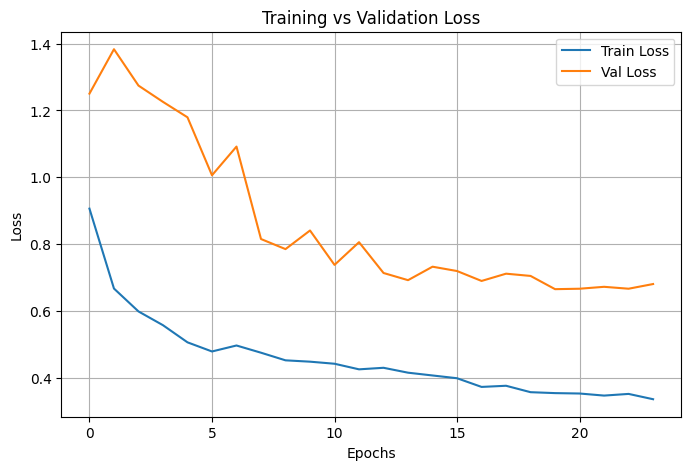

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()


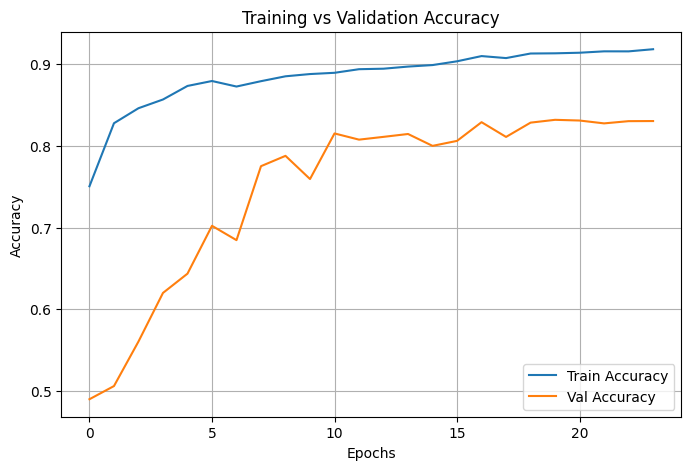

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Val Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
val_loss, val_acc = model.evaluate(X_val, y_val, verbose=1)
print(f"Validation Loss     : {val_loss:.4f}")
print(f"Validation Accuracy : {val_acc:.4f}")


3/3 ━━━━━━━━━━━━━━━━━━━━ 27s 6s/step - accuracy: 0.8324 - loss: 0.6553 
Validation Loss     : 0.6562
Validation Accuracy : 0.8316


In [ ]:
def build_cnn():
    inputs = Input((IMG_SIZE, IMG_SIZE, 3))


    x = Conv2D(32, 3, padding="same")(inputs)
    x = BatchNormalization()(x)
    x = Activation("relu")(x)
    x = MaxPooling2D()(x)

    x = Conv2D(64, 3, padding="same")(x)
    x = BatchNormalization()(x)
    x = Activation("relu")(x)
    x = MaxPooling2D()(x)

    x = Conv2D(128, 3, padding="same")(x)
    x = BatchNormalization()(x)
    x = Activation("relu")(x)


    x = UpSampling2D()(x)
    x = Conv2D(64, 3, padding="same", activation="relu")(x)

    x = UpSampling2D()(x)
    x = Conv2D(32, 3, padding="same", activation="relu")(x)

    outputs = Conv2D(1, 1, activation="sigmoid")(x)

    return Model(inputs, outputs)


In [ ]:
model = build_cnn()

model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=15,
    batch_size=4,
    verbose=1
)


Epoch 1/15


2026-01-29 13:47:39.551585: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-29 13:47:39.713302: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


75/75 ━━━━━━━━━━━━━━━━━━━━ 10s 56ms/step - accuracy: 0.6831 - loss: 0.5968 - val_accuracy: 0.3804 - val_loss: 0.7697
Epoch 2/15
75/75 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - accuracy: 0.7594 - loss: 0.4974 - val_accuracy: 0.3814 - val_loss: 0.7994
Epoch 3/15
75/75 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - accuracy: 0.7790 - loss: 0.4671 - val_accuracy: 0.3960 - val_loss: 0.8205
Epoch 4/15
75/75 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - accuracy: 0.7902 - loss: 0.4516 - val_accuracy: 0.4660 - val_loss: 0.7894
Epoch 5/15
75/75 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - accuracy: 0.8036 - loss: 0.4301 - val_accuracy: 0.5563 - val_loss: 0.6750
Epoch 6/15
75/75 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - accuracy: 0.7834 - loss: 0.4479 - val_accuracy: 0.6794 - val_loss: 0.5755
Epoch 7/15
75/75 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - accuracy: 0.7943 - loss: 0.4335 - val_accuracy: 0.6794 - val_loss: 0.5818
Epoch 8/15
75/75 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - accuracy: 0.8036 - loss: 0.4297 - val_accuracy: 0.7180 - val_loss: 0

In [ ]:
model.save("water_segmentation_model.h5")
print("Model saved successfully")


Model saved successfully


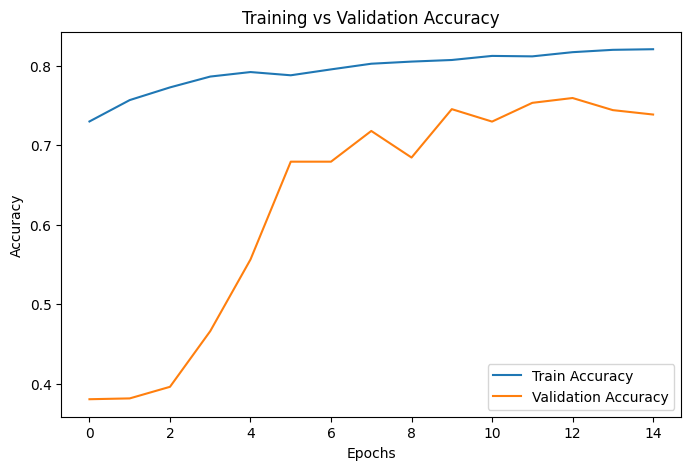

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.show()


In [ ]:
val_loss, val_acc = model.evaluate(X_val, y_val, verbose=1)
print(f"Validation Loss     : {val_loss:.4f}")
print(f"Validation Accuracy : {val_acc:.4f}")


3/3 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step - accuracy: 0.7400 - loss: 0.5174
Validation Loss     : 0.5219
Validation Accuracy : 0.7387


In [ ]:
def iou_score(y_true, y_pred, threshold=0.5):
    y_pred = (y_pred > threshold).astype("float32")
    intersection = np.sum(y_true * y_pred)
    union = np.sum(y_true) + np.sum(y_pred) - intersection
    return intersection / (union + 1e-7)



In [ ]:
def dice_score(y_true, y_pred, threshold=0.5):
    y_pred = (y_pred > threshold).astype("float32")
    intersection = np.sum(y_true * y_pred)
    return (2 * intersection) / (np.sum(y_true) + np.sum(y_pred) + 1e-7)


In [ ]:
preds = model.predict(X_val)

iou = iou_score(y_val, preds)
dice = dice_score(y_val, preds)

print(f"IoU Score  : {iou:.4f}")
print(f"Dice Score : {dice:.4f}")


3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 327ms/step
IoU Score  : 0.5096
Dice Score : 0.6751


In [ ]:
IMAGE_PATH = "/kaggle/input/water-segmentation-dataset/water_v1/water_v1/JPEGImages/ADE20K/ADE_train_00000191.png"
MASK_PATH  = "/kaggle/input/water-segmentation-dataset/water_v1/water_v1/Annotations/ADE20K/ADE_train_00000191.png"
MODEL_PATH = "/kaggle/working/water_segmentation_model.h5"


In [ ]:
IMG_SIZE = 256


In [ ]:
def load_image(path):
    img = cv2.imread(path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    img = img.astype(np.float32) / 255.0
    return img


In [ ]:
def load_mask(path):
    mask = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    mask = cv2.resize(mask, (IMG_SIZE, IMG_SIZE))
    mask = (mask > 0).astype(np.uint8)   # 0/255 → 0/1
    return mask


In [ ]:
image = load_image(IMAGE_PATH)
gt_mask = load_mask(MASK_PATH)


In [ ]:
model = tf.keras.models.load_model(MODEL_PATH)


In [ ]:
pred = model.predict(image[np.newaxis, ...], verbose=0)
pred_mask = (pred[0, :, :, 0] > 0.5).astype(np.uint8)


In [ ]:
def overlay(image, mask, color):
    out = image.copy()
    out[mask == 1] = color
    return (0.7 * image + 0.3 * out)


In [ ]:
gt_overlay = overlay(image, gt_mask, [0, 1, 0])
pred_overlay = overlay(image, pred_mask, [1, 0, 0])


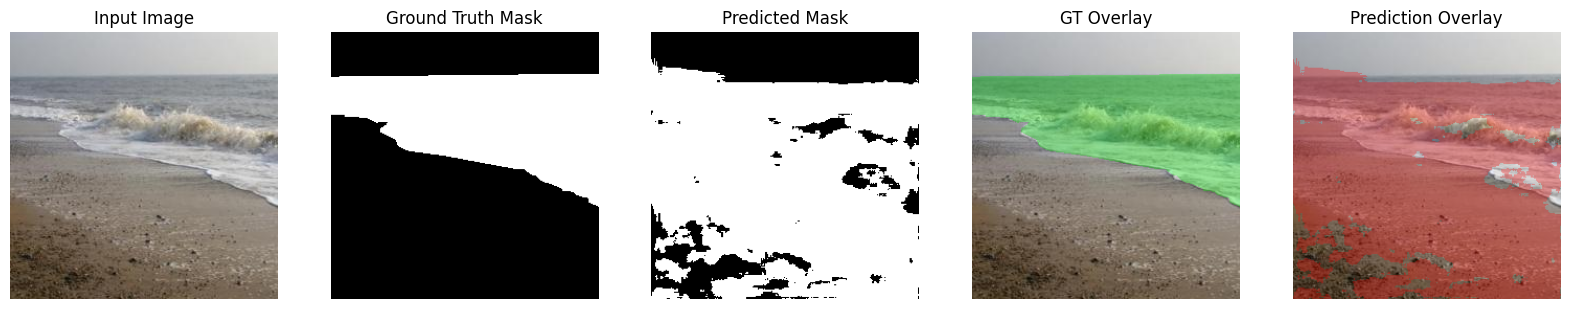

In [ ]:
plt.figure(figsize=(20, 5))

plt.subplot(1, 5, 1)
plt.imshow(image)
plt.title("Input Image")
plt.axis("off")

plt.subplot(1, 5, 2)
plt.imshow(gt_mask, cmap="gray")
plt.title("Ground Truth Mask")
plt.axis("off")

plt.subplot(1, 5, 3)
plt.imshow(pred_mask, cmap="gray")
plt.title("Predicted Mask")
plt.axis("off")

plt.subplot(1, 5, 4)
plt.imshow(gt_overlay)
plt.title("GT Overlay")
plt.axis("off")

plt.subplot(1, 5, 5)
plt.imshow(pred_overlay)
plt.title("Prediction Overlay")
plt.axis("off")

plt.show()
